In [35]:
"""
Challenge B — Quick exploration starter
Run this to see what the data looks like before building your solution.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from bucket_access.bucket_utils import list_files, download_file

# ── 1. List available files ──────────────────────────────────────────────────
print("=== Files in challengeB/ ===")
for f in list_files("challengeB/"):
    print(" ", f)


=== Files in challengeB/ ===
  challengeB/
  challengeB/spatial_brain_maps/
  challengeB/spatial_brain_maps/atlas_regions.csv
  challengeB/spatial_brain_maps/brain_atlas_anatomy.nii.gz
  challengeB/spatial_brain_maps/brain_atlas_regions.nii.gz
  challengeB/spatial_brain_maps/cfos_G001_median.nii.gz
  challengeB/spatial_brain_maps/cfos_G002_median.nii.gz
  challengeB/spatial_brain_maps/cfos_group_median_difference_G002_vs_G001.nii.gz
  challengeB/tabular_data_quantification/
  challengeB/tabular_data_quantification/cfos_object_density_quantification.csv
  challengeB/tabular_data_quantification/cfos_object_density_statistics_G002_vs_G001.csv


In [36]:

# ── 2. Download tabular data ─────────────────────────────────────────────────
os.makedirs("data_b", exist_ok=True)
print("\nDownloading tabular data...")
download_file(
    "challengeB/tabular_data_quantification/cfos_object_density_quantification.csv",
    "data_b/quantification.csv"
)
download_file(
    "challengeB/tabular_data_quantification/cfos_object_density_statistics_G002_vs_G001.csv",
    "data_b/statistics.csv"
)

# ── 3. Load and explore ───────────────────────────────────────────────────────
quant = pd.read_csv("data_b/quantification.csv")
stats = pd.read_csv("data_b/statistics.csv")

print(f"\n=== Quantification data ===")
print(f"  Shape: {quant.shape}  ({quant['group_nr'].value_counts().to_dict()})")
print(quant[["scan_name", "animal_nr", "group_nr"]].head(6).to_string(index=False))

print(f"\n=== Statistics data ===")
print(f"  Shape: {stats.shape}")
print(f"  Columns: {list(stats.columns)}")
sig_corrected = stats[stats["significant_corrected"] == True].shape[0]
sig_uncorrected = stats[stats["significant_uncorrected"] == True].shape[0]
print(f"\n  Significant (corrected p<0.05):   {sig_corrected} regions")
print(f"  Significant (uncorrected p<0.05): {sig_uncorrected} regions")



✓ Downloaded → data_b/quantification.csv
✓ Downloaded → data_b/statistics.csv

=== Quantification data ===
  Shape: (12, 1359)  ({'G002': 6, 'G001': 6})
                                       scan_name animal_nr group_nr
260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32     AN0B2     G002
260219_AN0B4_G002_mouse_brain_MB1_SCAN0_14-05-25     AN0B4     G002
260219_AN0B7_G002_mouse_brain_MB1_SCAN0_16-11-05     AN0B7     G002
260220_AN0A4_G001_mouse_brain_MB1_SCAN0_13-28-02     AN0A4     G001
260223_AN0A7_G001_mouse_brain_MB1_SCAN0_10-31-31     AN0A7     G001
260224_AN0A2_G001_mouse_brain_MB1_SCAN0_09-09-05     AN0A2     G001

=== Statistics data ===
  Shape: (1356, 28)
  Columns: ['region_id', 'region_name', 'acronym', 'hierarchy_level', 'is_lowest_level', 'n_A', 'n_B', 'n_A_eff', 'n_B_eff', 'mean_A', 'mean_B', 'median_A', 'median_B', 'std_A', 'std_B', 'sem_A', 'sem_B', 'mean_diff', 'ci_low', 'ci_high', 'fold_change', 'log2_fold_change', 'log2fc_ci_low', 'log2fc_ci_high', 'p_value', 'p_co

In [37]:

# ── 4. Top differentially activated regions ───────────────────────────────────
print("\n=== Top 10 UPREGULATED in Semaglutide (G002) ===")
up = stats.nlargest(10, "log2_fold_change")[
    ["acronym", "region_name", "log2_fold_change", "p_corrected", "significant_corrected"]
]
print(up.to_string(index=False))

print("\n=== Top 10 DOWNREGULATED in Semaglutide (G002) ===")
down = stats.nsmallest(10, "log2_fold_change")[
    ["acronym", "region_name", "log2_fold_change", "p_corrected", "significant_corrected"]
]
print(down.to_string(index=False))



=== Top 10 UPREGULATED in Semaglutide (G002) ===
acronym                              region_name  log2_fold_change  p_corrected  significant_corrected
    NTS            Nucleus of the solitary tract          2.767218     0.499750                    0.0
   dscp superior cerebellar peduncle decussation          2.519495     1.000000                    0.0
    INC            Interstitial nucleus of Cajal          2.176332     0.890194                    0.0
    MEV              Midbrain trigeminal nucleus          2.167492     0.818594                    0.0
    III                       Oculomotor nucleus          2.136428     1.000000                    0.0
    DMX  Dorsal motor nucleus of the vagus nerve          2.039545     0.504850                    0.0
     MD          Mediodorsal nucleus of thalamus          1.955321     0.493376                    0.0
     Xn                              vagus nerve          1.884917          NaN                    NaN
     ts                


Generating volcano plot...
  Saved: challenge_b_volcano.png


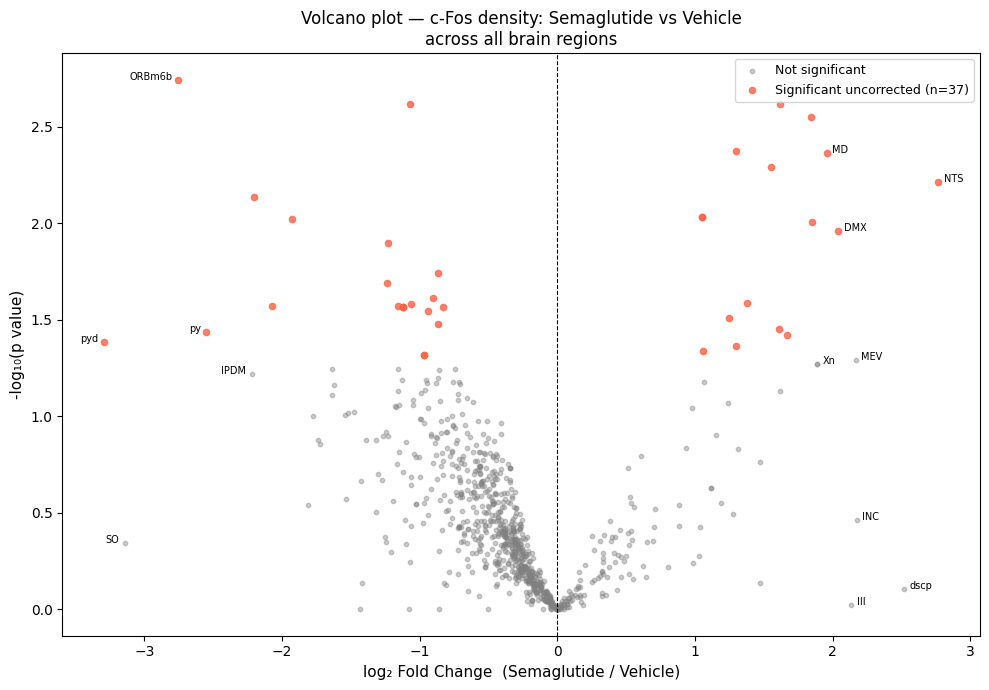

In [38]:
# ── 5. Volcano plot ───────────────────────────────────────────────────────────
print("\nGenerating volcano plot...")

fig, ax = plt.subplots(figsize=(10, 7))

# colour by uncorrected significance (no regions survive corrected p<0.05)
not_sig = stats[stats["significant_uncorrected"] != True]
sig = stats[stats["significant_uncorrected"] == True]

ax.scatter(not_sig["log2_fold_change"], -np.log10(not_sig["p_value"]),
           s=10, alpha=0.4, color="grey", label="Not significant")
ax.scatter(sig["log2_fold_change"], -np.log10(sig["p_value"]),
           s=20, alpha=0.8, color="tomato", label=f"Significant uncorrected (n={len(sig)})")

# label top hits
for _, row in stats.nlargest(8, "log2_fold_change").iterrows():
    ax.annotate(row["acronym"], (row["log2_fold_change"], -np.log10(row["p_value"])),
                fontsize=7, ha="left", xytext=(4, 0), textcoords="offset points")
for _, row in stats.nsmallest(5, "log2_fold_change").iterrows():
    ax.annotate(row["acronym"], (row["log2_fold_change"], -np.log10(row["p_value"])),
                fontsize=7, ha="right", xytext=(-4, 0), textcoords="offset points")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("log₂ Fold Change  (Semaglutide / Vehicle)", fontsize=11)
ax.set_ylabel("-log₁₀(p value)", fontsize=11)
ax.set_title("Volcano plot — c-Fos density: Semaglutide vs Vehicle\nacross all brain regions", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("challenge_b_volcano.png", dpi=130)
print("  Saved: challenge_b_volcano.png")

Based on the data we already loaded, here's what the plot is showing:

X-axis (log2 fold change): How much more or less c-Fos (neuronal activity) there is in Semaglutide mice vs control. Positive = more active in Semaglutide, negative = less active.

Y-axis (-log10 p-value): Statistical confidence. Higher up = more significant.

What the pattern means:

Most brain regions (grey) show no meaningful difference — Semaglutide doesn't broadly rewire the brain
The 37 red dots are scattered across both sides — the drug both activates and suppresses specific regions
The strongest upregulated hit is NTS (Nucleus of the solitary tract, log2FC=2.77), alongside DMX (Dorsal motor nucleus of the vagus nerve) — these are exactly the brainstem regions involved in hunger suppression and gut-brain signaling, which is precisely how Ozempic is thought to work
The strongest downregulated hit is SO (Supraoptic nucleus, log2FC=-3.14), which regulates fluid balance and stress hormones
The biological story: The drug is specifically activating the vagus nerve/brainstem circuit that signals fullness and suppressing hypothalamic regions — consistent with the known mechanism of GLP-1 agonists reducing appetite. That's a genuinely interesting result to present.

  Saved: challenge_b_top_regions.png


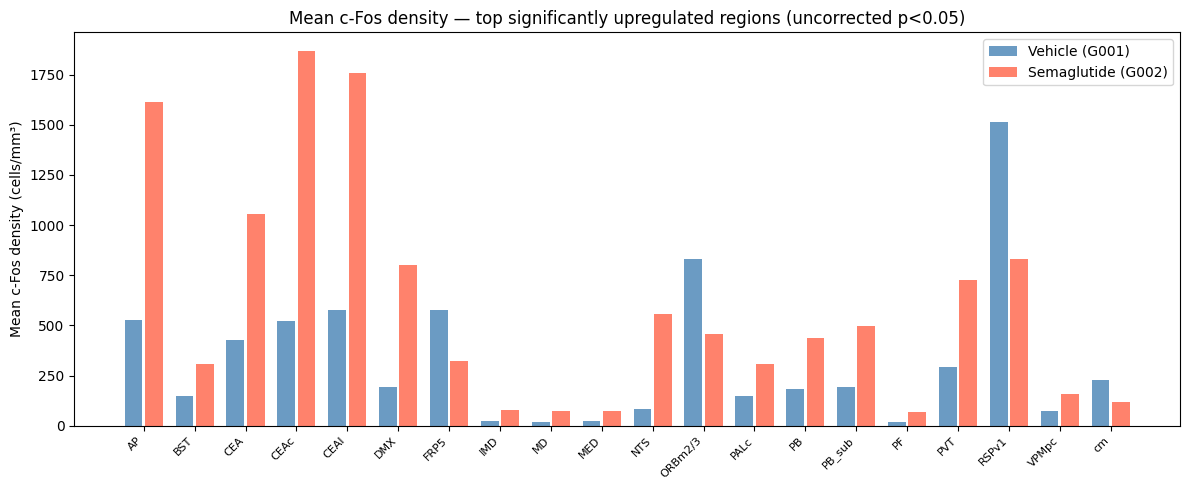

In [39]:
# ── 6. Distribution of c-Fos by region (top 20 uncorrected significant regions) ──────────
top_regions = stats[stats["significant_uncorrected"] == True].nlargest(20, "log2_fold_change")["acronym"].tolist()
region_cols = [c for c in quant.columns if c in top_regions]

if region_cols:
    long_df = quant.melt(
        id_vars=["group_nr"], value_vars=region_cols,
        var_name="region", value_name="density"
    )
    g001 = long_df[long_df["group_nr"] == "G001"].groupby("region")["density"].mean()
    g002 = long_df[long_df["group_nr"] == "G002"].groupby("region")["density"].mean()
    merged = pd.DataFrame({"Vehicle (G001)": g001, "Semaglutide (G002)": g002}).dropna()
    merged = merged.loc[merged.index.isin(region_cols)]

    fig2, ax2 = plt.subplots(figsize=(12, 5))
    x = np.arange(len(merged))
    ax2.bar(x - 0.2, merged["Vehicle (G001)"], 0.35, label="Vehicle (G001)", color="steelblue", alpha=0.8)
    ax2.bar(x + 0.2, merged["Semaglutide (G002)"], 0.35, label="Semaglutide (G002)", color="tomato", alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(merged.index, rotation=45, ha="right", fontsize=8)
    ax2.set_ylabel("Mean c-Fos density (cells/mm³)")
    ax2.set_title("Mean c-Fos density — top significantly upregulated regions (uncorrected p<0.05)")
    ax2.legend()
    plt.tight_layout()
    plt.savefig("challenge_b_top_regions.png", dpi=130)
    print("  Saved: challenge_b_top_regions.png")
else:
    print("  No matching region columns found in quantification data")

In [40]:

print("\nDone! Open challenge_b_volcano.png to see the full picture.")
print("\nNext steps for Challenge B:")
print("  1. Run `python challenge_b_agent.py` to chat with Claude about the data")
print("  2. Build a Streamlit/Dash dashboard using the volcano + bar plots above")
print("  3. Add NIfTI spatial brain maps for the coolest visual extension")



Done! Open challenge_b_volcano.png to see the full picture.

Next steps for Challenge B:
  1. Run `python challenge_b_agent.py` to chat with Claude about the data
  2. Build a Streamlit/Dash dashboard using the volcano + bar plots above
  3. Add NIfTI spatial brain maps for the coolest visual extension


In [41]:
from bucket_access.bucket_utils import download_file
import SimpleITK as sitk
import numpy as np
import pandas as pd

download_file('challengeB/spatial_brain_maps/brain_atlas_anatomy.nii.gz',     'anatomy.nii.gz')
download_file('challengeB/spatial_brain_maps/brain_atlas_regions.nii.gz',     'regions.nii.gz')
download_file('challengeB/spatial_brain_maps/cfos_G001_median.nii.gz',        'cfos_G001.nii.gz')
download_file('challengeB/spatial_brain_maps/cfos_G002_median.nii.gz',        'cfos_G002.nii.gz')
download_file('challengeB/spatial_brain_maps/cfos_group_median_difference_G002_vs_G001.nii.gz',
                                                                               'diff_map.nii.gz')
download_file('challengeB/spatial_brain_maps/atlas_regions.csv',            'atlas_regions.csv')

# load volumes
anatomy_img  = sitk.ReadImage('anatomy.nii.gz')
regions_img  = sitk.ReadImage('regions.nii.gz')
cfos_g001    = sitk.ReadImage('cfos_G001.nii.gz')
cfos_g002    = sitk.ReadImage('cfos_G002.nii.gz')
diff_img     = sitk.ReadImage('diff_map.nii.gz')

# convert to numpy arrays — shape is (X, Y, Z) in SimpleITK
anatomy      = sitk.GetArrayFromImage(anatomy_img)   # returns (Z, Y, X)
regions      = sitk.GetArrayFromImage(regions_img).astype(int)
diff_map     = sitk.GetArrayFromImage(diff_img)

# voxel size in mm
voxel_size   = anatomy_img.GetSpacing()   # (x, y, z) in mm

# atlas regions (columns: id, parent_id, aibs_id, name, acronym, red, green, blue)
hierarchy    = pd.read_csv('atlas_regions.csv')
print("Atlas columns:", hierarchy.columns.tolist())
print(hierarchy.head(3))

# coronal slice at midpoint (axis 1 = anterior-posterior in Z,Y,X array)
mid          = anatomy.shape[1] // 2
anatomy_slice = anatomy[:, mid, :]
diff_slice    = diff_map[:, mid, :]

# binary mask for a specific region by acronym (column is 'id', not 'label')
matches = hierarchy[hierarchy['acronym'] == 'PVT']
if not matches.empty:
    label_id     = matches['id'].values[0]
    region_mask  = regions == label_id
    print(f"PVT label_id: {label_id}, voxels: {region_mask.sum()}")
else:
    print("PVT not found in atlas")

✓ Downloaded → anatomy.nii.gz
✓ Downloaded → regions.nii.gz
✓ Downloaded → cfos_G001.nii.gz
✓ Downloaded → cfos_G002.nii.gz
✓ Downloaded → diff_map.nii.gz
✓ Downloaded → atlas_regions.csv
Atlas columns: ['id', 'parent_id', 'aibs_id', 'aibs_parent_id', 'name', 'acronym', 'red', 'green', 'blue']
     id  parent_id  aibs_id  aibs_parent_id                           name  \
0  5000          0      997             NaN                           root   
1  5001       5000        8           997.0  Basic cell groups and regions   
2  5002       5001      567             8.0                       Cerebrum   

  acronym  red  green  blue  
0    root  255    255   255  
1    grey  191    218   227  
2      CH  176    240   255  
PVT label_id: 5694, voxels: 17272


Significant regions matched to atlas: 37 / 37


/var/folders/3b/_701tnqj0_545vycfpjds_1r0000gn/T/ipykernel_8515/1000505581.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: challenge_b_atlas_projection.png


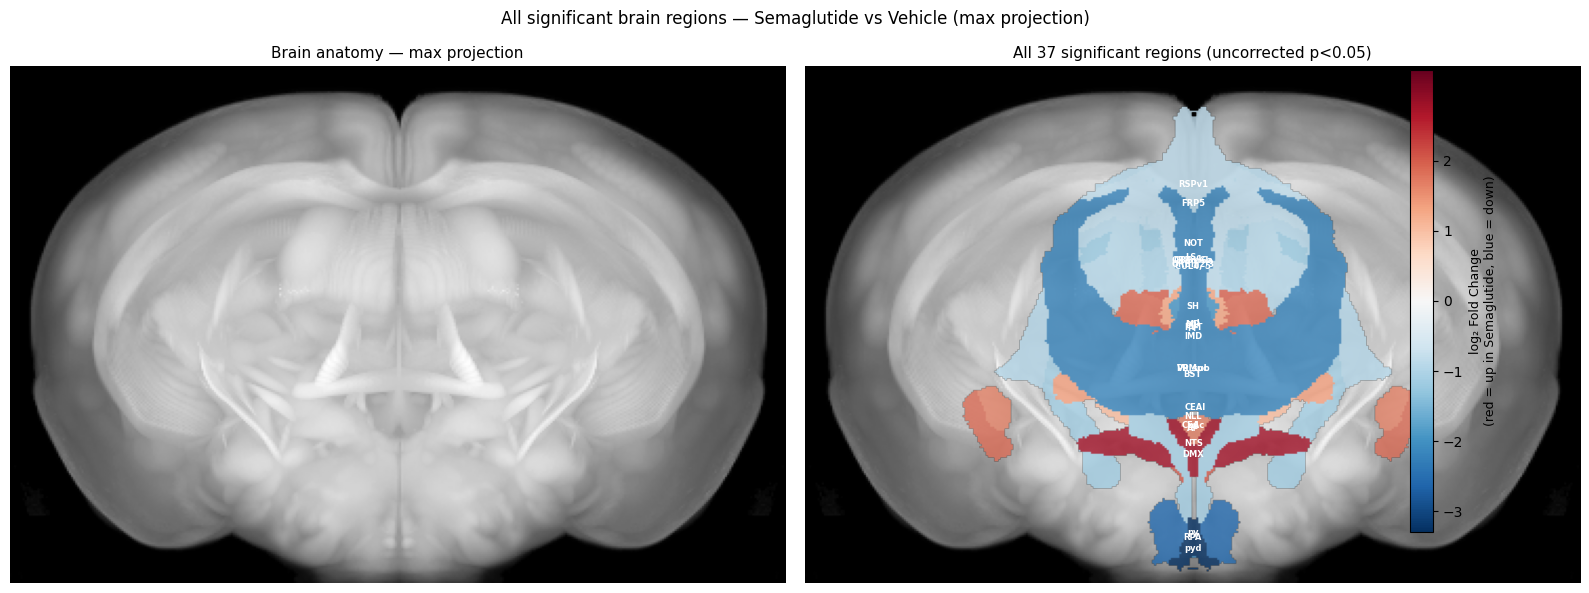

In [42]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# get significant regions with their fold change, matched to atlas
sig = stats[stats["significant_uncorrected"] == True][["acronym", "log2_fold_change"]].copy()
sig = sig.merge(hierarchy[["acronym", "id"]], on="acronym", how="inner")
print(f"Significant regions matched to atlas: {len(sig)} / {stats['significant_uncorrected'].eq(True).sum()}")

vmax = sig["log2_fold_change"].abs().max()
cmap = plt.cm.RdBu_r
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)

# max projection along anterior-posterior axis (axis=1) → shows ALL regions
anat_proj = anatomy.max(axis=1)   # (Z, X)

# build 2D fold-change map: each pixel gets the FC of whichever region occupies it
fc_proj = np.full(anat_proj.shape, np.nan)
for _, row in sig.iterrows():
    mask_2d = (regions == row["id"]).max(axis=1)
    fc_proj[mask_2d] = row["log2_fold_change"]

# RGBA overlay
overlay = np.zeros((*anat_proj.shape, 4), dtype=float)
valid = ~np.isnan(fc_proj)
overlay[valid] = cmap(norm(fc_proj[valid]))
overlay[valid, 3] = 0.8

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(anat_proj, cmap="gray", origin="lower", aspect="auto")
axes[0].set_title("Brain anatomy — max projection", fontsize=11)
axes[0].axis("off")

axes[1].imshow(anat_proj, cmap="gray", origin="lower", aspect="auto")
axes[1].imshow(overlay, origin="lower", aspect="auto")
axes[1].set_title(f"All {len(sig)} significant regions (uncorrected p<0.05)", fontsize=11)
axes[1].axis("off")

for _, row in sig.iterrows():
    mask_2d = (regions == row["id"]).max(axis=1)
    if mask_2d.any():
        ys, xs = np.where(mask_2d)
        axes[1].text(xs.mean(), ys.mean(), row["acronym"],
                     fontsize=6, color="white", ha="center", va="center", fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("log₂ Fold Change\n(red = up in Semaglutide, blue = down)", fontsize=9)

plt.suptitle("All significant brain regions — Semaglutide vs Vehicle (max projection)", fontsize=12)
plt.tight_layout()
plt.savefig("challenge_b_atlas_projection.png", dpi=130, bbox_inches="tight")
print("Saved: challenge_b_atlas_projection.png")

Saved: challenge_b_fc_thresholds.png


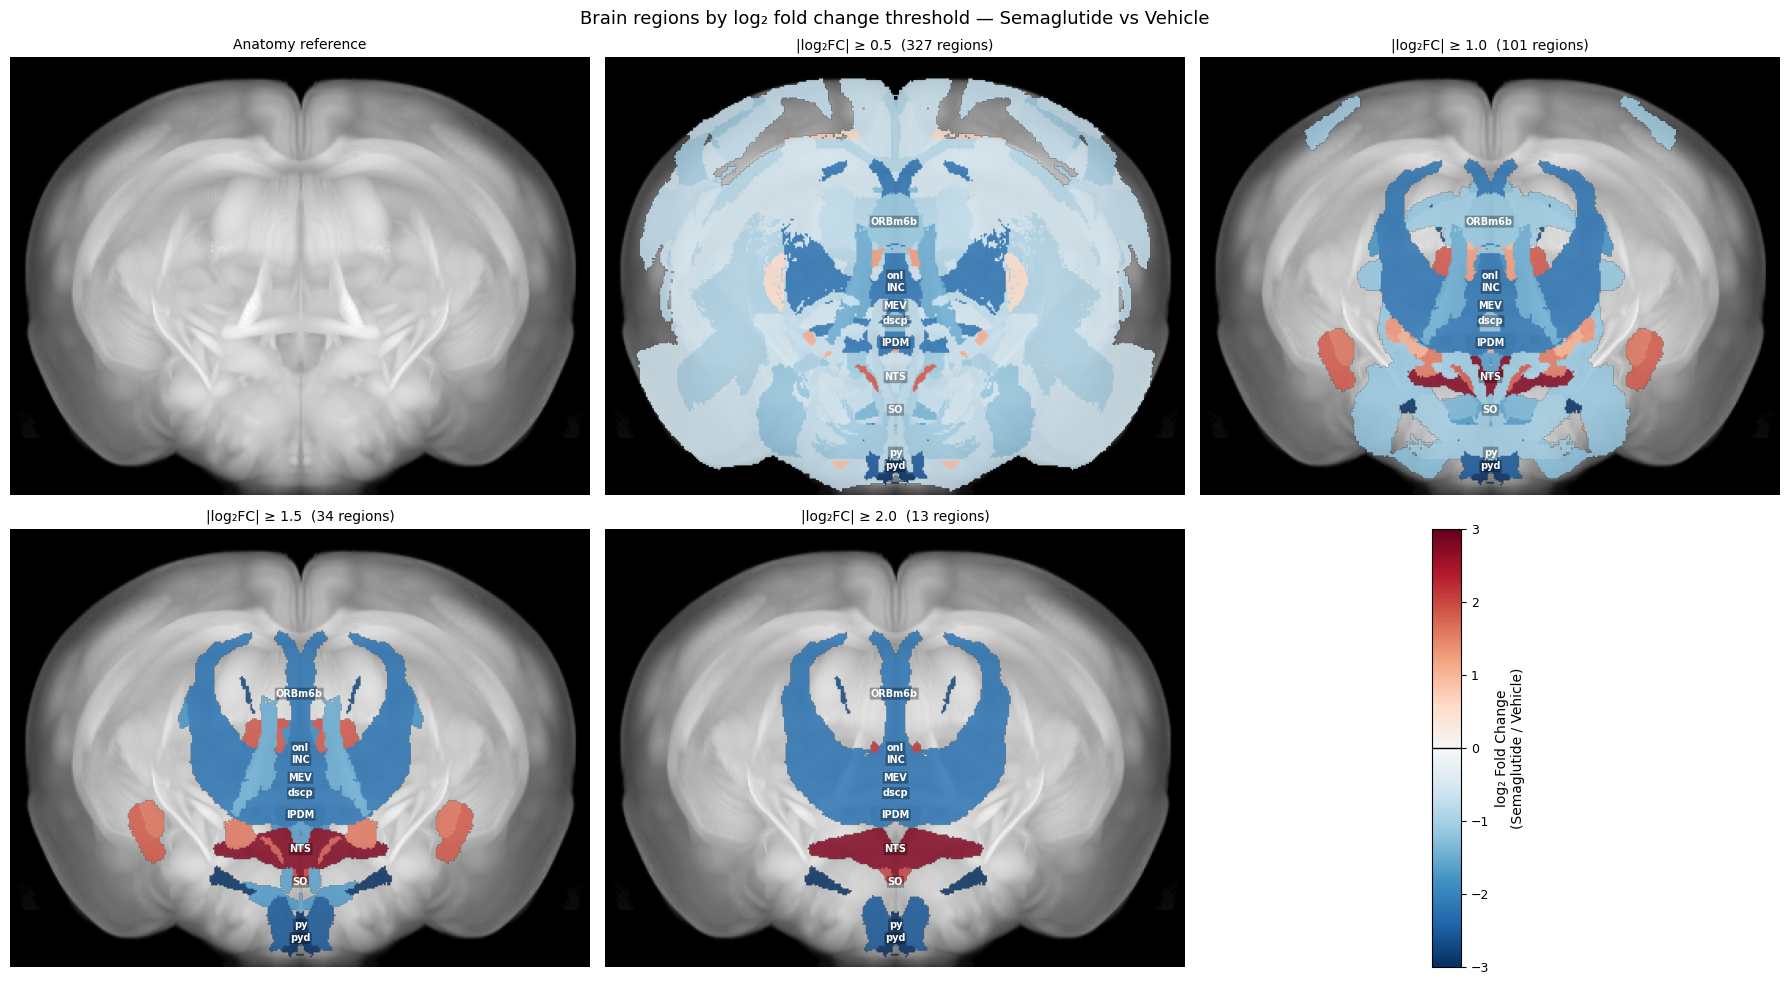

In [43]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

all_regions = stats[["acronym", "log2_fold_change"]].dropna()
all_regions = all_regions.merge(hierarchy[["acronym", "id"]], on="acronym", how="inner")

anat_proj = anatomy.max(axis=1)
thresholds = [0.5, 1.0, 1.5, 2.0]

vmax = 3.0
cmap = plt.cm.RdBu_r
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

axes[0].imshow(anat_proj, cmap="gray", origin="lower", aspect="auto")
axes[0].set_title("Anatomy reference", fontsize=10)
axes[0].axis("off")

for i, thresh in enumerate(thresholds):
    ax = axes[i + 1]
    subset = all_regions[all_regions["log2_fold_change"].abs() >= thresh]

    fc_proj = np.full(anat_proj.shape, np.nan)
    for _, row in subset.iterrows():
        mask_2d = (regions == row["id"]).max(axis=1)
        fc_proj[mask_2d] = row["log2_fold_change"]

    overlay = np.zeros((*anat_proj.shape, 4), dtype=float)
    valid = ~np.isnan(fc_proj)
    overlay[valid] = cmap(norm(fc_proj[valid]))
    overlay[valid, 3] = 0.85

    ax.imshow(anat_proj, cmap="gray", origin="lower", aspect="auto")
    ax.imshow(overlay, origin="lower", aspect="auto")
    ax.set_title(f"|log₂FC| ≥ {thresh}  ({len(subset)} regions)", fontsize=10)
    ax.axis("off")

    # only label top 10 by absolute fold change to avoid clutter
    top = subset.reindex(subset["log2_fold_change"].abs().nlargest(10).index)
    for _, row in top.iterrows():
        mask_2d = (regions == row["id"]).max(axis=1)
        if mask_2d.any():
            ys, xs = np.where(mask_2d)
            ax.text(xs.mean(), ys.mean(), row["acronym"],
                    fontsize=7, color="white", ha="center", va="center",
                    fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.3, lw=0))

axes[5].axis("off")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[5], fraction=0.6, pad=0.05, aspect=15)
cbar.set_label("log₂ Fold Change\n(Semaglutide / Vehicle)", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cbar.ax.axhline(0, color="black", linewidth=1)

plt.suptitle("Brain regions by log₂ fold change threshold — Semaglutide vs Vehicle", fontsize=13)
plt.tight_layout()
plt.savefig("challenge_b_fc_thresholds.png", dpi=130, bbox_inches="tight")
print("Saved: challenge_b_fc_thresholds.png")

Significant regions found in quantification data: 37 / 37
Saved: challenge_b_clustermap.png


/var/folders/3b/_701tnqj0_545vycfpjds_1r0000gn/T/ipykernel_8515/1077523615.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = plt.cm.get_cmap("tab10", k)


Saved: challenge_b_cluster_brain.png


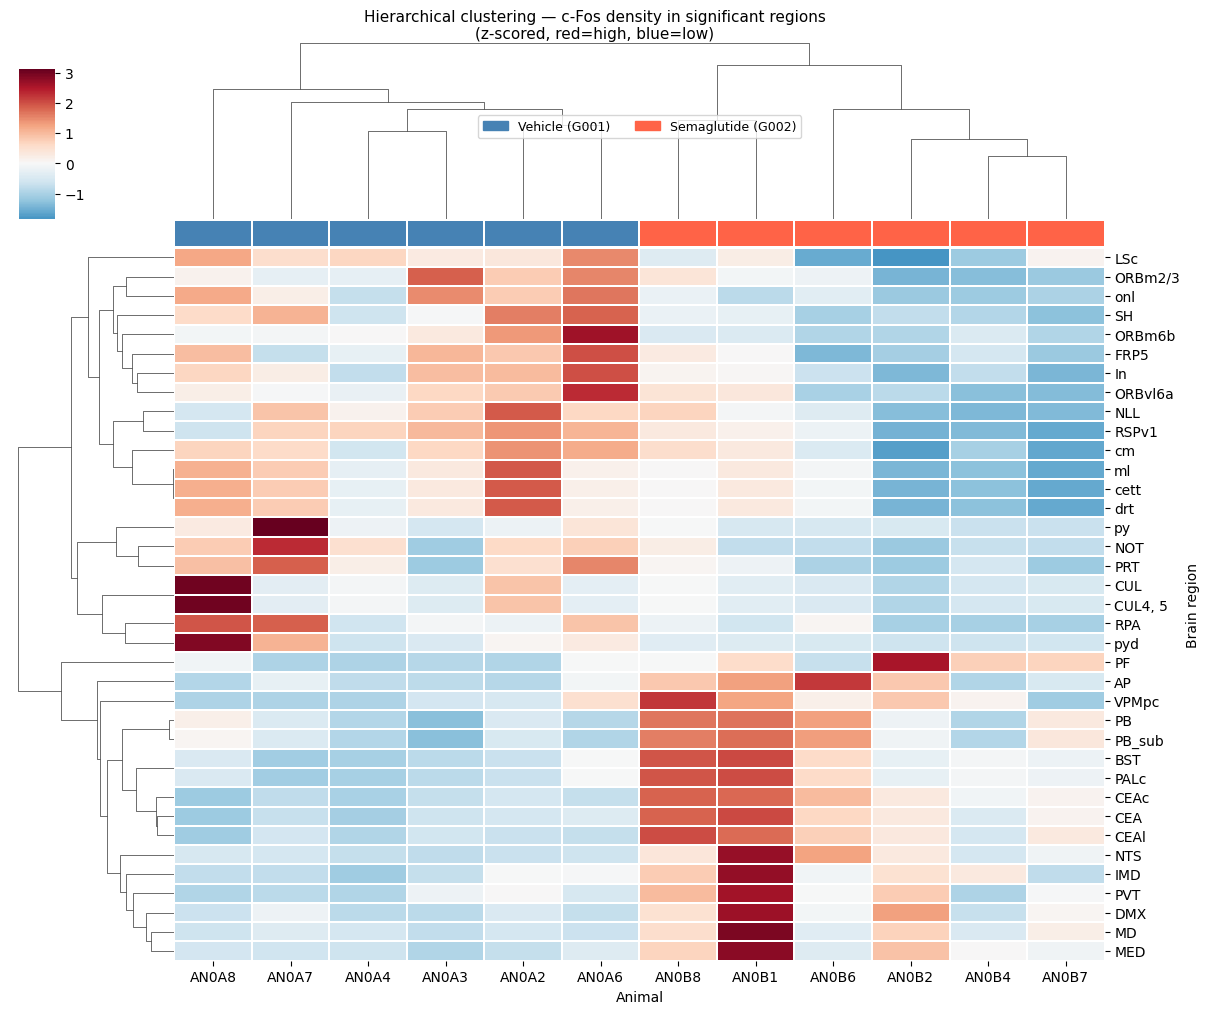

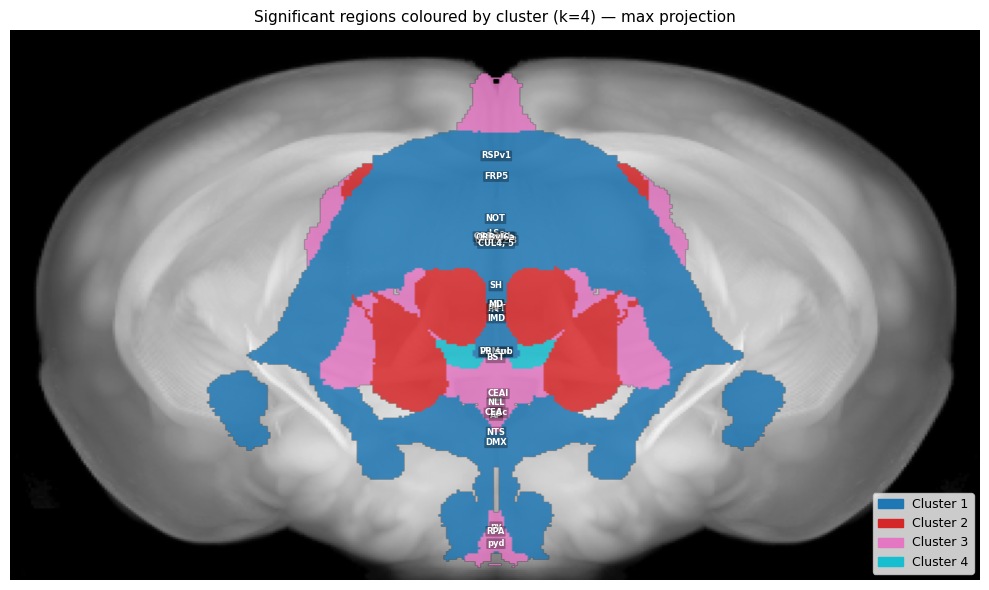

In [44]:
import seaborn as sns
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── 1. Get significant region names that exist in quantification data ─────────
sig_acronyms = stats[stats["significant_uncorrected"] == True]["acronym"].tolist()
region_cols  = [c for c in quant.columns if c in sig_acronyms]
print(f"Significant regions found in quantification data: {len(region_cols)} / {len(sig_acronyms)}")

# matrix: animals × regions, z-scored per region
X = quant[["group_nr"] + region_cols].copy()
mat = X[region_cols].values.astype(float)
mat_z = StandardScaler().fit_transform(mat)   # z-score each region across animals
df_z = pd.DataFrame(mat_z, columns=region_cols, index=quant["animal_nr"])

# ── 2. Clustermap — regions × animals with dendrograms ────────────────────────
group_colors = quant["group_nr"].map({"G001": "steelblue", "G002": "tomato"}).values

g = sns.clustermap(
    df_z.T,                         # regions as rows, animals as columns
    cmap="RdBu_r", center=0,
    col_colors=group_colors,
    figsize=(12, 10),
    dendrogram_ratio=(0.15, 0.2),
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    linewidths=0.3,
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xlabel("Animal", fontsize=10)
g.ax_heatmap.set_ylabel("Brain region", fontsize=10)
g.fig.suptitle("Hierarchical clustering — c-Fos density in significant regions\n(z-scored, red=high, blue=low)",
               y=1.01, fontsize=11)

# legend for group colours
from matplotlib.patches import Patch
g.ax_col_dendrogram.legend(
    handles=[Patch(color="steelblue", label="Vehicle (G001)"),
             Patch(color="tomato",    label="Semaglutide (G002)")],
    loc="center", ncol=2, fontsize=9
)
plt.savefig("challenge_b_clustermap.png", dpi=130, bbox_inches="tight")
print("Saved: challenge_b_clustermap.png")

# ── 3. Cut dendrogram into k clusters, show on brain ─────────────────────────
k = 4
row_linkage = g.dendrogram_row.linkage
cluster_labels = fcluster(row_linkage, k, criterion="maxclust")
region_clusters = dict(zip(
    [region_cols[i] for i in g.dendrogram_row.reordered_ind],
    cluster_labels
))

cluster_cmap = plt.cm.get_cmap("tab10", k)
anat_proj = anatomy.max(axis=1)
atlas_df  = hierarchy[["acronym", "id"]]

overlay = np.zeros((*anat_proj.shape, 4), dtype=float)
for acronym, cl in region_clusters.items():
    match = atlas_df[atlas_df["acronym"] == acronym]
    if match.empty:
        continue
    rid = match["id"].values[0]
    mask_2d = (regions == rid).max(axis=1)
    color = cluster_cmap(cl - 1)
    overlay[mask_2d] = [color[0], color[1], color[2], 0.85]

fig2, ax = plt.subplots(figsize=(10, 6))
ax.imshow(anat_proj, cmap="gray", origin="lower", aspect="auto")
ax.imshow(overlay, origin="lower", aspect="auto")
ax.axis("off")
ax.set_title(f"Significant regions coloured by cluster (k={k}) — max projection", fontsize=11)

for acronym, cl in region_clusters.items():
    match = atlas_df[atlas_df["acronym"] == acronym]
    if match.empty:
        continue
    rid = match["id"].values[0]
    mask_2d = (regions == rid).max(axis=1)
    if mask_2d.any():
        ys, xs = np.where(mask_2d)
        ax.text(xs.mean(), ys.mean(), acronym, fontsize=6, color="white",
                ha="center", va="center", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.3, lw=0))

handles = [Patch(color=cluster_cmap(i), label=f"Cluster {i+1}") for i in range(k)]
ax.legend(handles=handles, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("challenge_b_cluster_brain.png", dpi=130, bbox_inches="tight")
print("Saved: challenge_b_cluster_brain.png")

Saved: challenge_b_clustermap_k6.png
Saved: challenge_b_correlation.png


/var/folders/3b/_701tnqj0_545vycfpjds_1r0000gn/T/ipykernel_8515/2318919945.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = plt.cm.get_cmap("tab10", k)



Network: 37 nodes, 152 edges (|r| ≥ 0.7)
Saved: challenge_b_network.png


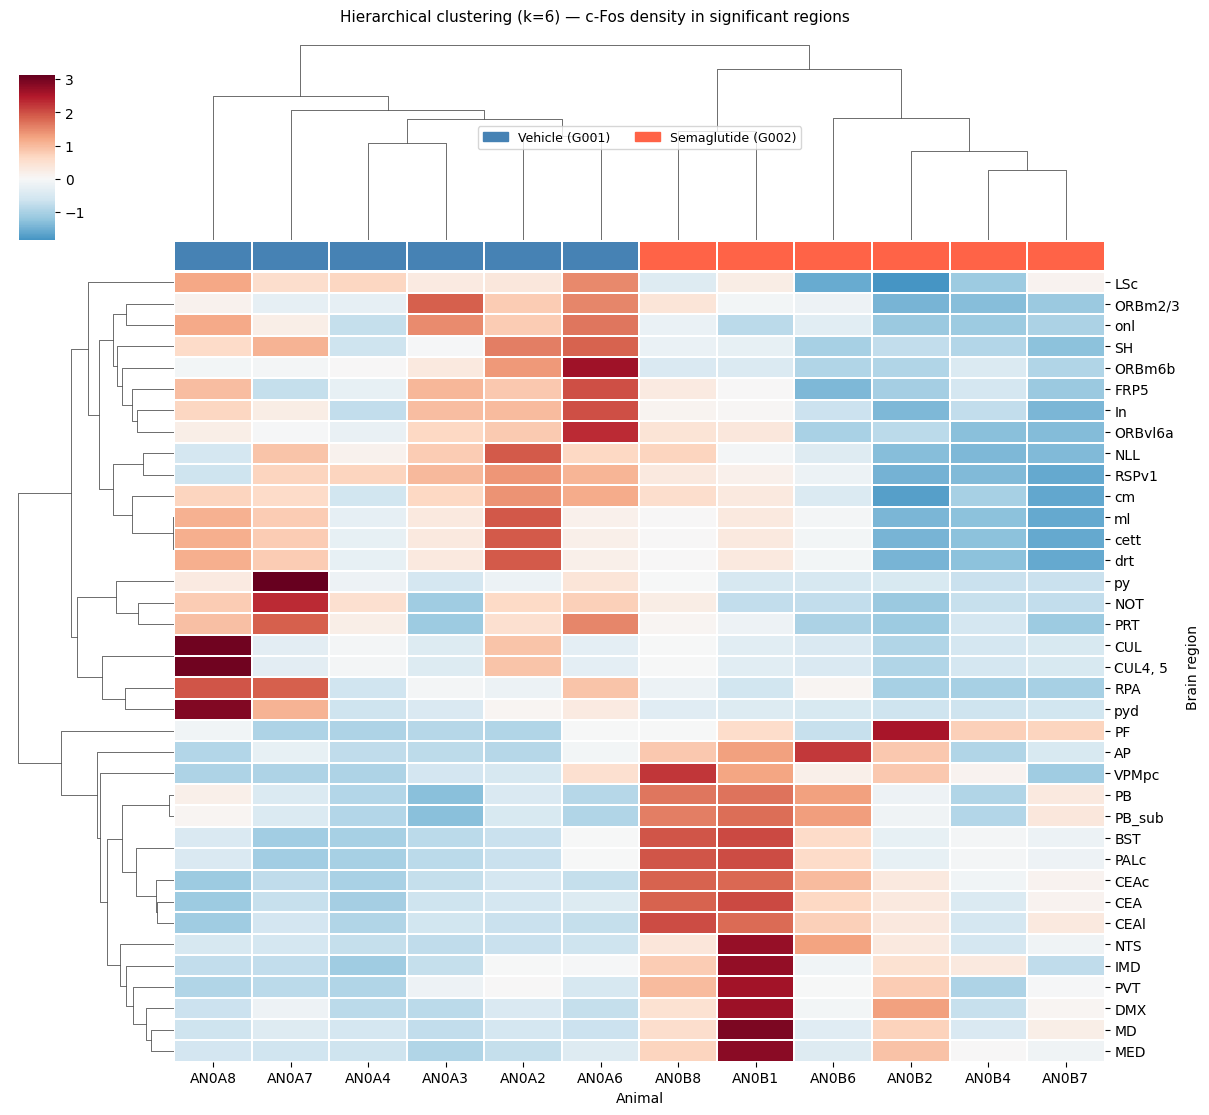

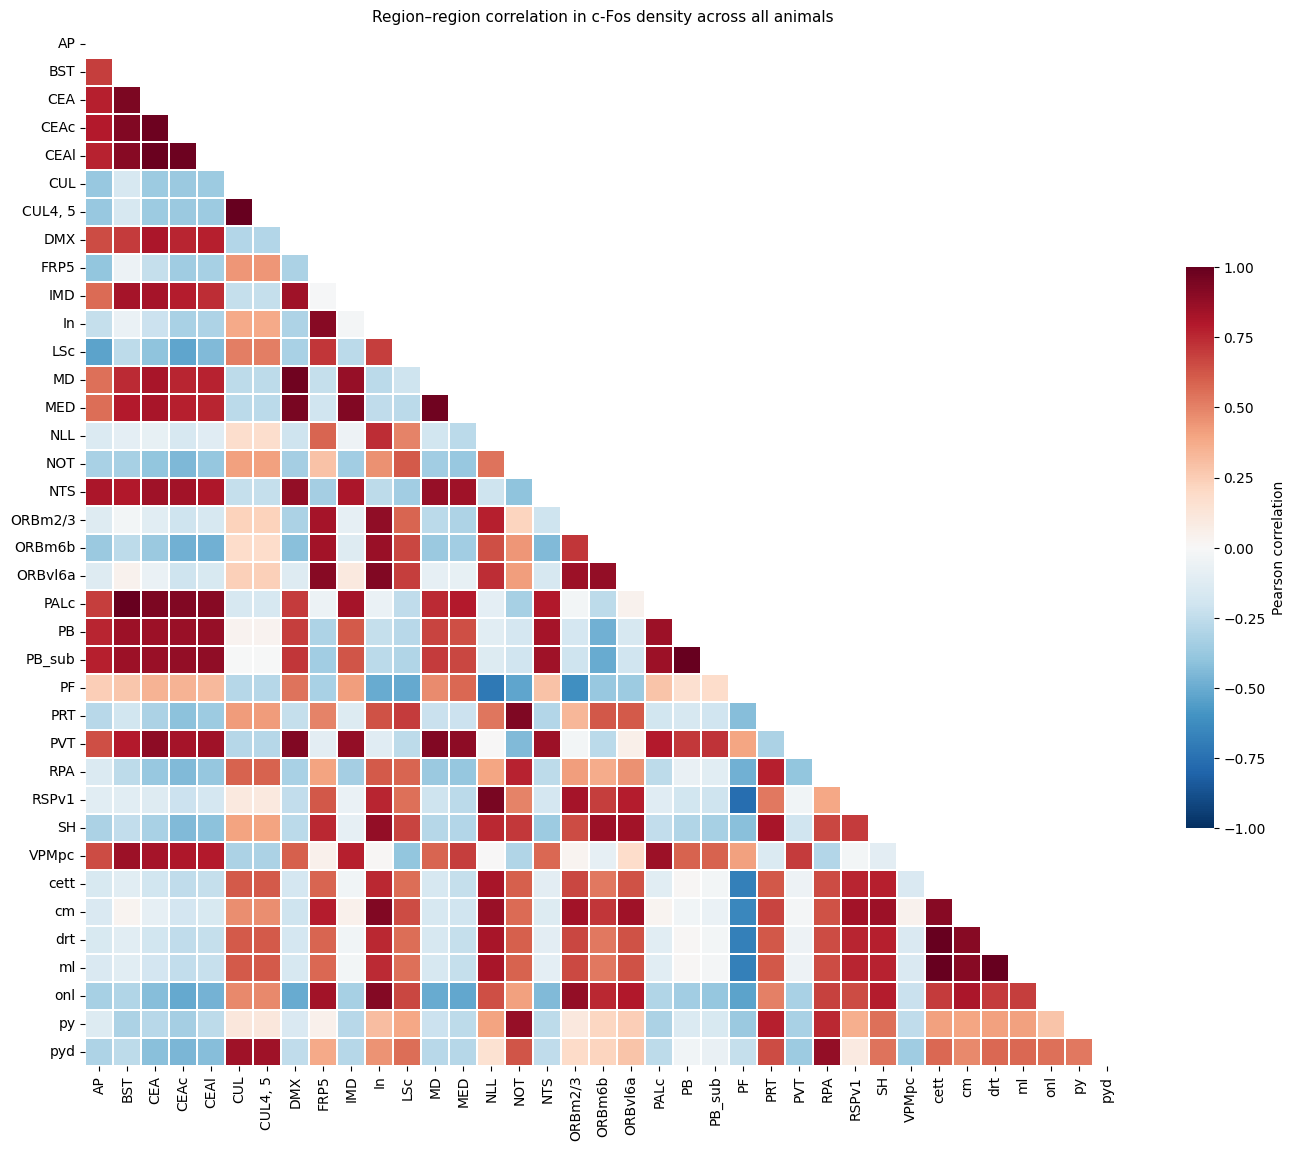

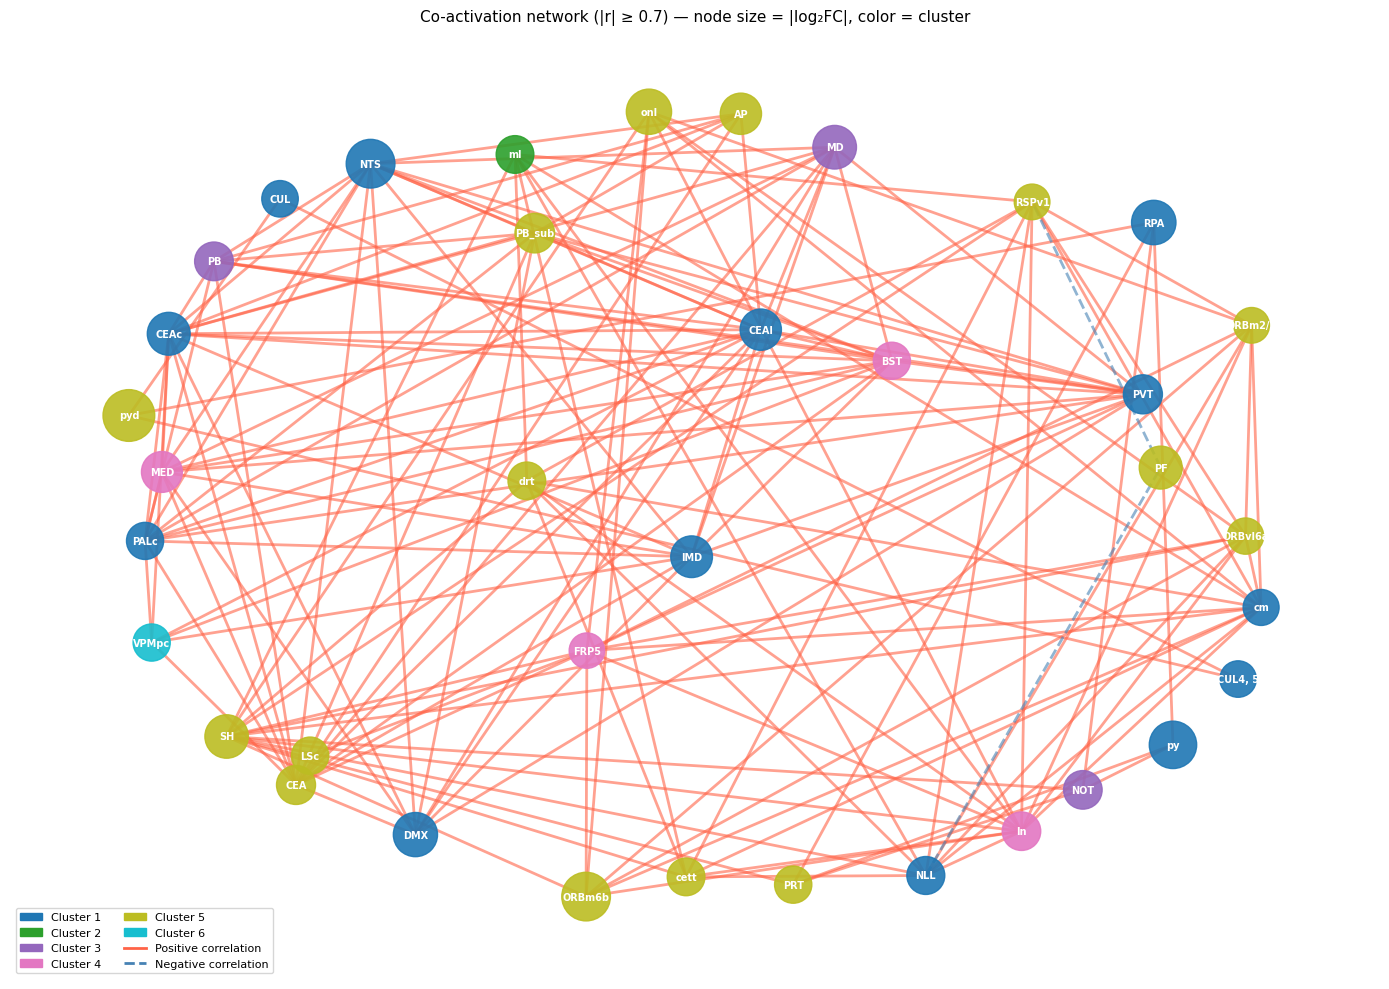

In [45]:
import seaborn as sns
from scipy.cluster.hierarchy import fcluster
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import networkx as nx
import numpy as np

# ── data prep ─────────────────────────────────────────────────────────────────
sig_acronyms = stats[stats["significant_uncorrected"] == True]["acronym"].tolist()
region_cols  = [c for c in quant.columns if c in sig_acronyms]

mat   = quant[region_cols].values.astype(float)
mat_z = StandardScaler().fit_transform(mat)
df_z  = pd.DataFrame(mat_z, columns=region_cols, index=quant["animal_nr"])

group_colors = quant["group_nr"].map({"G001": "steelblue", "G002": "tomato"}).values

# ── 1. Clustermap with k=6 ────────────────────────────────────────────────────
k = 6
g = sns.clustermap(
    df_z.T,
    cmap="RdBu_r", center=0,
    col_colors=group_colors,
    figsize=(12, 11),
    dendrogram_ratio=(0.15, 0.2),
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    linewidths=0.3,
    yticklabels=True, xticklabels=True,
)
g.ax_heatmap.set_xlabel("Animal", fontsize=10)
g.ax_heatmap.set_ylabel("Brain region", fontsize=10)
g.fig.suptitle(f"Hierarchical clustering (k={k}) — c-Fos density in significant regions", y=1.01, fontsize=11)
g.ax_col_dendrogram.legend(
    handles=[Patch(color="steelblue", label="Vehicle (G001)"),
             Patch(color="tomato",    label="Semaglutide (G002)")],
    loc="center", ncol=2, fontsize=9
)
plt.savefig("challenge_b_clustermap_k6.png", dpi=130, bbox_inches="tight")
print("Saved: challenge_b_clustermap_k6.png")

cluster_labels = fcluster(g.dendrogram_row.linkage, k, criterion="maxclust")
region_clusters = dict(zip(
    [region_cols[i] for i in g.dendrogram_row.reordered_ind],
    cluster_labels
))

# ── 2. Correlation matrix ─────────────────────────────────────────────────────
corr = df_z[region_cols].corr()

fig2, ax2 = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax2, square=True, linewidths=0.3,
            cbar_kws={"label": "Pearson correlation", "shrink": 0.5})
ax2.set_title("Region–region correlation in c-Fos density across all animals", fontsize=11)
plt.tight_layout()
plt.savefig("challenge_b_correlation.png", dpi=130, bbox_inches="tight")
print("Saved: challenge_b_correlation.png")

# ── 3. Network graph: nodes = regions, edges = strong correlations ────────────
threshold = 0.7   # only draw edges for |r| >= 0.7
G = nx.Graph()
cluster_cmap = plt.cm.get_cmap("tab10", k)

for region in region_cols:
    cl = region_clusters.get(region, 1)
    fc = stats[stats["acronym"] == region]["log2_fold_change"].values
    G.add_node(region, cluster=cl, fc=fc[0] if len(fc) else 0)

for i, r1 in enumerate(region_cols):
    for j, r2 in enumerate(region_cols):
        if j <= i:
            continue
        r, _ = pearsonr(df_z[r1], df_z[r2])
        if abs(r) >= threshold:
            G.add_edge(r1, r2, weight=abs(r), sign="pos" if r > 0 else "neg")

print(f"\nNetwork: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges (|r| ≥ {threshold})")

fig3, ax3 = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=2.5)

node_colors = [cluster_cmap(G.nodes[n]["cluster"] - 1) for n in G.nodes]
node_sizes  = [400 + 300 * abs(G.nodes[n]["fc"]) for n in G.nodes]

pos_edges = [(u, v) for u, v, d in G.edges(data=True) if d["sign"] == "pos"]
neg_edges = [(u, v) for u, v, d in G.edges(data=True) if d["sign"] == "neg"]

nx.draw_networkx_edges(G, pos, edgelist=pos_edges, ax=ax3,
                       edge_color="tomato", alpha=0.6, width=2)
nx.draw_networkx_edges(G, pos, edgelist=neg_edges, ax=ax3,
                       edge_color="steelblue", alpha=0.6, width=2, style="dashed")
nx.draw_networkx_nodes(G, pos, ax=ax3, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax3, font_size=7, font_color="white", font_weight="bold")

cluster_handles = [Patch(color=cluster_cmap(i), label=f"Cluster {i+1}") for i in range(k)]
edge_handles = [
    plt.Line2D([0], [0], color="tomato",    linewidth=2, label="Positive correlation"),
    plt.Line2D([0], [0], color="steelblue", linewidth=2, linestyle="dashed", label="Negative correlation"),
]
ax3.legend(handles=cluster_handles + edge_handles, loc="lower left", fontsize=8, ncol=2)
ax3.set_title(f"Co-activation network (|r| ≥ {threshold}) — node size = |log₂FC|, color = cluster", fontsize=11)
ax3.axis("off")
plt.tight_layout()
plt.savefig("challenge_b_network.png", dpi=130, bbox_inches="tight")
print("Saved: challenge_b_network.png")